In [1]:
import matplotlib
from matplotlib import pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
from shapely.geometry import Polygon

In [2]:
SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

matplotlib.rc("font", size=SMALL_SIZE)          # controls default text sizes
matplotlib.rc("axes", titlesize=MEDIUM_SIZE)     # fontsize of the axes title
matplotlib.rc("axes", labelsize=SMALL_SIZE)    # fontsize of the x and y labels
matplotlib.rc("xtick", labelsize=SMALL_SIZE)    # fontsize of the tick labels
matplotlib.rc("ytick", labelsize=SMALL_SIZE)    # fontsize of the tick labels
matplotlib.rc("legend", fontsize=SMALL_SIZE)    # legend fontsize
matplotlib.rc("figure", titlesize=MEDIUM_SIZE)  # fontsize of the figure title

In [3]:
def get_aspect(ax=None):
    if ax is None:
        ax = plt.gca()
    fig = ax.figure

    ll, ur = ax.get_position() * fig.get_size_inches()
    width, height = ur - ll
    axes_ratio = height / width
    aspect = axes_ratio / ax.get_data_ratio()

    return aspect

In [4]:
def intersect_piecewise(X1, X2):
    x = np.union1d(X1[0], X2[0])
    y1 = np.interp(x, X1[0], X1[1])
    y2 = np.interp(x, X2[0], X2[1])
    dy = y1 - y2

    ind = (dy[:-1] * dy[1:] < 0).nonzero()[0]
    x1, x2 = x[ind], x[ind+1]
    dy1, dy2 = dy[ind], dy[ind+1]
    y11, y12 = y1[ind], y1[ind+1]
    y21, y22 = y2[ind], y2[ind+1]

    x_int = x1 - (x2 - x1) * dy1 / (dy2 - dy1)
    y_int = y11 + (y12 - y11) * (x_int - x1) / (x2 - x1)
    return x_int, y_int

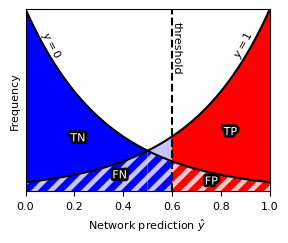

In [7]:
x = np.linspace(0, 1, 10000)
a = 3
threshold = 0.6
positive_func, negative_func = lambda x: np.exp(a*(x-1)), lambda x: np.exp(-a*x)
positive_derivative_func, negative_derivative_func = lambda x: a*np.exp(a*(x-1)), lambda x: -a*np.exp(-a*x)
positive, negative = positive_func(x), negative_func(x)
intersect = intersect_piecewise(np.array([x, positive]), np.array([x, negative]))
intersect = intersect[0][0]
tp_color = "#ff0000"
fp_color = "#ffc4c4"
tn_color = "#0000ff"
fn_color = "#c4c4ff"

fig, ax = plt.subplots(figsize=(8/2.54, 6/2.54))
ax.plot(x, positive, c="k")
label = 0.92
delta = 0.05
num = 100
mean = np.mean(positive_derivative_func(np.linspace(label-delta, label+delta, num)))
rotation = 180/np.pi*np.arctan(get_aspect(ax)*mean)
ax.text(label, positive_func(label), r"$y=1$", rotation=rotation, 
        ha="center", va="bottom", rotation_mode="anchor")
ax.plot(x, negative, c="k")
label = 1 - label
mean = np.mean(negative_derivative_func(np.linspace(label-delta, label+delta, num)))
rotation = 180/np.pi*np.arctan(get_aspect(ax)*mean)
ax.text(label, negative_func(label), r"$y=0$", rotation=rotation, 
        ha="center", va="bottom", rotation_mode="anchor")
ax.axvline(threshold, c="k", ls="--")
ax.text(threshold, negative_func(label), "threshold", rotation=-90, va="center")

mask = np.logical_and(x<=threshold, x<=intersect)
ax.fill_between(x[mask], negative[mask], positive[mask], color=tn_color)
ax.fill_between(x[mask], 0, positive[mask], hatch=r"//", hatch_linewidth=5, ec=tn_color, fc=fn_color, lw=0)

mask = np.logical_and(x>intersect, x<=threshold)
ax.fill_between(x[mask], negative[mask], 0, hatch=r"//", hatch_linewidth=5, ec=tn_color, fc=fn_color, lw=0)
ax.fill_between(x[mask], negative[mask], positive[mask], color=fn_color)

mask = np.logical_and(x>threshold, x>intersect)
ax.fill_between(x[mask], negative[mask], positive[mask], color=tp_color)
ax.fill_between(x[mask], negative[mask], 0, hatch=r"//", hatch_linewidth=5, ec=tp_color, fc=fp_color, lw=0)

mask = np.logical_and(x>threshold, x<=intersect)
ax.fill_between(x[mask], 0, positive[mask], hatch=r"//", hatch_linewidth=5, ec=tp_color, fc=fp_color, lw=0)
ax.fill_between(x[mask], negative[mask], positive[mask], color=fp_color)

mask = x<=threshold
polygon = Polygon([*np.array([x[mask], negative[mask]]).T, [threshold, 0], [0, 0]])
ax.text(polygon.centroid.x, polygon.centroid.y, "TN", 
        ha="center", va="center", c="white", path_effects=[pe.withStroke(linewidth=4, foreground="k")])
polygon = Polygon([*np.array([x[mask], positive[mask]]).T, [threshold, 0], [0, 0]])
ax.text(polygon.centroid.x, polygon.centroid.y, "FN", 
        ha="center", va="center", c="white", path_effects=[pe.withStroke(linewidth=4, foreground="k")])
mask = x>threshold
polygon = Polygon([*np.array([x[mask], positive[mask]]).T, [1, 0], [threshold, 0]])
ax.text(polygon.centroid.x, polygon.centroid.y, "TP", 
        ha="center", va="center", c="white", path_effects=[pe.withStroke(linewidth=4, foreground="k")])
polygon = Polygon([*np.array([x[mask], negative[mask]]).T, [1, 0], [threshold, 0]])
ax.text(polygon.centroid.x, polygon.centroid.y, "FP", 
        ha="center", va="center", c="white", path_effects=[pe.withStroke(linewidth=4, foreground="k")])


ax.set_ylabel(r"Frequency")
ax.set_yticks([])
ax.set_xlabel(r"Network prediction $\hat{y}$")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

fig.savefig("threshold.png", dpi=300, bbox_inches="tight")